In [1]:
import datetime

import pandas as pd
import numpy as np
import pickle as pkl
import multiprocessing as mp
import matplotlib.pyplot as plt

from statsmodels.distributions.empirical_distribution import ECDF
from skfda.exploratory.depth import ModifiedBandDepth
from functional_utils import _confidence_bands_from_eCDF
from scipy import stats
from functools import partial

from sklearn.neighbors import KernelDensity

from ffc_utils import (_fknn_forecast_dynamic_update,
                       _functional_downsampling, 
                       _focal_curve_envelope, 
                       _functional_confidence_band,
                       _silverman_rule)

from scores_utils import _empirical_PIT, _KS

path_to_data = '/home/gterren/dynamic_update/data'
path_to_validation = '/home/gterren/dynamic_update/validation'
path_to_param = '/home/gterren/dynamic_update/params'
path_to_test = '/home/gterren/dynamic_update/test'

# Calibration experiments setup
T = 288
resource = 'solar'
method   = 'fusion'

In [2]:
# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
print(F_tr_.shape, E_tr_.shape)
    
# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order  = {v: i for i, v in enumerate(assets_tr_)}
idx_   = np.argsort([order[x] for x in assets_ts_])
F_ts_  = F_ts_[:, :, idx_]
E_ts_  = E_ts_[:, :, idx_]
print(F_ts_.shape, E_ts_.shape)

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.
print(F_tr_.max(), E_tr_.max())
print(F_tr_.max(), E_tr_.min())

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.
print(F_ts_.max(), F_ts_.max())
print(F_ts_.min(), E_ts_.min())

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_bias_ = E_ts_.copy()
E_tr_bias_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
print(E_tr_bias_.shape, E_ts_bias_.shape)

(363, 288, 211) (363, 288, 211)
(364, 288, 211) (364, 288, 211)
1.0 1.0
1.0 0.0
1.0 1.0
0.0 0.0
(76593, 288) (364, 288, 211)


(363, 288, 211) (363, 288, 211)


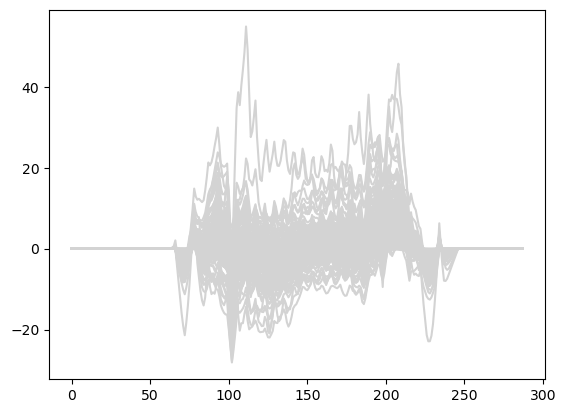

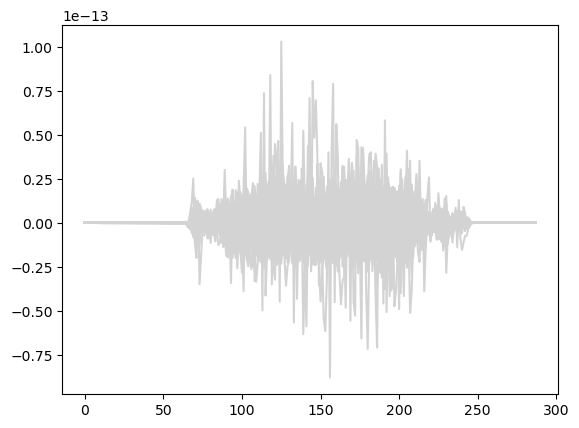

(364, 288, 211) (364, 288, 211)


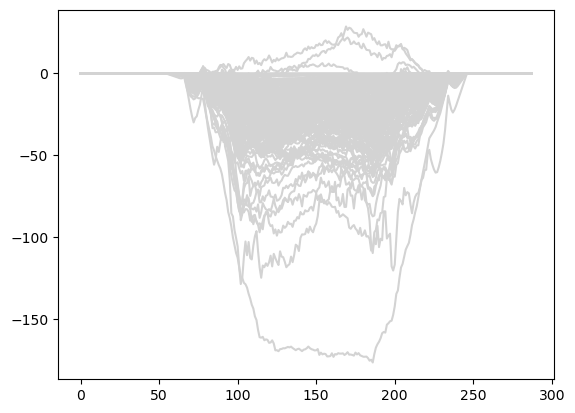

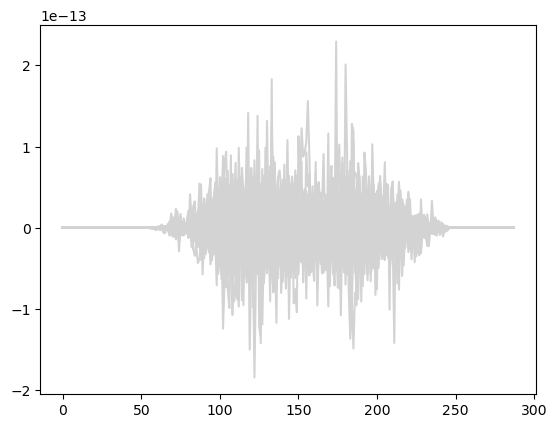

In [3]:
# Load 2017 data as training set
with open(path_to_data + f"/linear_preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
print(F_tr_.shape, E_tr_.shape)

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Unbias training set
B_tr_ = np.mean(F_tr_ - E_tr_, axis = 0)
for i in range(E_tr_.shape[-1]):
    E_tr_[:, :, i] += B_tr_[:, i]

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Load 2018 data as testing set
with open(path_to_data + f"/linear_preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order  = {v: i for i, v in enumerate(assets_tr_)}
idx_   = np.argsort([order[x] for x in assets_ts_])
F_ts_  = F_ts_[:, :, idx_]
E_ts_  = E_ts_[:, :, idx_]
print(F_ts_.shape, E_ts_.shape)

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# Unbias testing set
B_ts_ = np.mean(F_ts_ - E_ts_, axis = 0)
for i in range(E_ts_.shape[-1]):
    E_ts_[:, :, i] += B_ts_[:, i]

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
# print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_lin_ = E_ts_.copy()
E_tr_lin_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(E_tr_lin_.shape, E_ts_lin_.shape)

(363, 288, 211) (363, 288, 211) (363, 288)


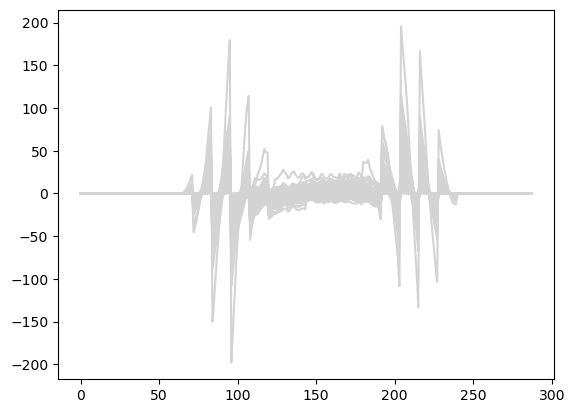

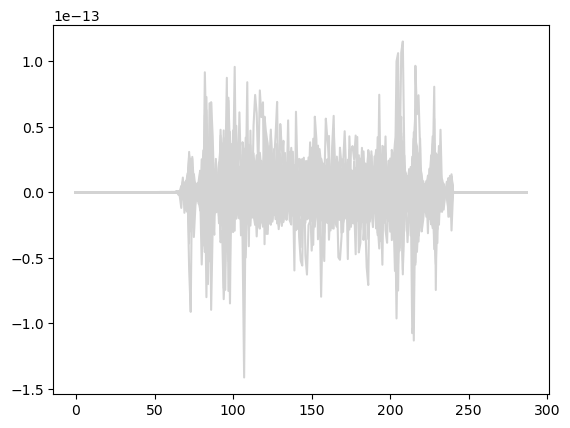

(364, 288, 211) (364, 288, 211) (364, 288)


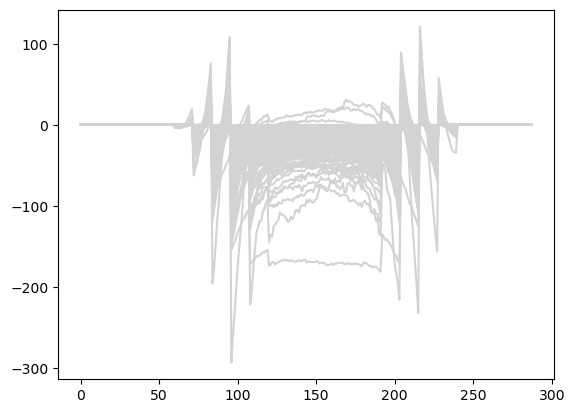

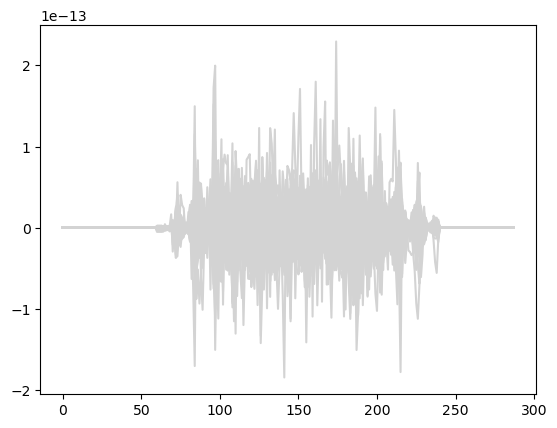

In [4]:
# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
x_tr_      = _data["locations"]
dates_tr_  = _data["dates"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, x_tr_.shape, dates_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
T_tr_ = dates_tr_.reshape(int(dates_tr_.shape[0]/T), T)
print(F_tr_.shape, E_tr_.shape, T_tr_.shape)

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Unbias training set
B_tr_ = np.mean(F_tr_ - E_tr_, axis = 0)
for i in range(E_tr_.shape[-1]):
    E_tr_[:, :, i] += B_tr_[:, i]

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
x_ts_      = _data["locations"]
dates_ts_  = _data["dates"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, x_ts_.shape, dates_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
T_ts_ = dates_ts_.reshape(int(dates_ts_.shape[0]/T), T)
print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

dt_ = np.array([t * 5 for t in range(T)])
dx_ = pd.to_datetime(pd.DataFrame({"time": dt_}).time, unit = "m").dt.strftime("%H:%M").to_numpy()
#print(dt_.shape, dx_.shape)

# Short testing set with training set order
order      = {v: i for i, v in enumerate(assets_tr_)}
idx_       = np.argsort([order[x] for x in assets_ts_])
assets_ts_ = assets_ts_[idx_]
x_ts_      = x_ts_[idx_]
F_ts_      = F_ts_[:, :, idx_]
E_ts_      = E_ts_[:, :, idx_]
#print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# Unbias testing set
B_ts_ = np.mean(F_ts_ - E_ts_, axis = 0)
for i in range(E_ts_.shape[-1]):
    E_ts_[:, :, i] += B_ts_[:, i]
    
plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
T_tr_ = np.concatenate([T_tr_ for k in range(assets_tr_.shape[0])], axis = 0)
assets_tr_ = np.concatenate([np.tile(assets_tr_[k], (F_tr_.shape[0], 1)) for k in range(assets_tr_.shape[0])], axis = 0)
x_tr_ = np.concatenate([np.tile(x_tr_[k, :], (F_tr_.shape[0], 1)) for k in range(x_tr_.shape[0])], axis = 0)
F_tr_ = np.concatenate([F_tr_[..., k] for k in range(F_tr_.shape[2])], axis = 0)
E_tr_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(x_tr_.shape, assets_tr_.shape, F_tr_.shape, E_tr_.shape, T_tr_.shape)
#print(x_ts_.shape, assets_ts_.shape, F_ts_.shape, E_ts_.shape, T_ts_.shape)

t_tr_ = np.array([datetime.datetime.strptime(t_tr, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_tr in T_tr_[:, 0]]) - 1
t_ts_ = np.array([datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_ts in T_ts_[:, 0]]) - 1
#print(t_tr_.shape, t_ts_.shape)

In [5]:
def _plot_PIT(_ax, u_, bins=10, title="PIT Histogram"):
    """
    Make a PIT histogram with a Uniform(0,1) reference line.
    Uses matplotlib, one chart, no explicit colors.
    """

    # histogram as density so the uniform reference is y=1
    counts_, bins, patches = _ax.hist(u_, 
                                     bins=bins, 
                                     range=(0.0, 1.0), 
                                     density=True, 
                                     edgecolor='black', 
                                     alpha = 0.5)   

    _ax.axhline(1.0, linestyle='--', color='red')
    _ax.set_xlim(0, 1)
    _ax.set_ylim(0, )

    _ax.set_xlabel("u = F̂(y_obs)")
    _ax.set_ylabel("Density")
    _ax.set_title(title)

def _KS(pit_):
    pit_ = np.asarray(pit_, dtype=float)
    pit_ = pit_[np.isfinite(pit_)]
    pit_ = np.clip(pit_, 0.0, 1.0)
    return stats.kstest(pit_, 'uniform').statistic

def _run_ffc(day, asset):

    file_name = f'{asset}-{day}-{time}'
    #print(f'Processing file {file_name}...')

    # Get functional predictors for a given test
    f_     = F_ts_[day, :time, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    e_     = E_ts_[day, :, asset]
    x_ts   = x_ts_[asset, :]
    t_ts   = t_ts_[day]
    f_hat_ = F_ts_[day, time:, asset]
    e_hat_ = E_ts_[day, time:, asset]

    # Filter solar hours with loading solar set
    #idx_days_  = np.absolute(t_tr_ - day) < 28
    #idx_hours_ = np.mean(F_tr_[idx_days_, :], axis = 0) > .25

    idx_days_  = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_bias_[idx_days_, :], axis = 0)) > 1.
    
    _meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_ts, t_ts,
                                              forget_rate_f = hyper_.loc['forget_rate_f'][time],
                                              forget_rate_e = hyper_.loc['forget_rate_e'][time],
                                              length_scale_f = hyper_.loc['length_scale_f'][time],
                                              length_scale_e = hyper_.loc['length_scale_e'][time],
                                              lookup_rate = hyper_.loc['lookup_rate'][time],
                                              trust_rate = hyper_.loc['trust_rate'][time],
                                              gamma = hyper_.loc['gamma'][time],
                                              xi = hyper_.loc['xi'][time],
                                              nu = hyper_.loc['nu'][time],
                                              kappa = hyper_.loc['kappa'][time],
                                              p_fusion = hyper_.loc['p_fusion'][time], 
                                              idx_hours_ = idx_hours_)

    #M_p_, f_p_ = _bias_correction(M_, _meta['focal_curve'], bias_, time, scale = 0.5)
    M_p_ = M_ 
    f_p_ = _meta['focal_curve'].copy()

    N = np.array([_meta['idx_neighbors'].shape[0], 
                  _meta['idx_temporal'].shape[0], 
                  _meta['idx_spatial'].shape[0]])

    return [M_p_, f_hat_, e_hat_, f_p_, file_name, N]

def _run_parallel(n_workers = 32, 
                  assets_ = range(5), 
                  indices_ = range(363)):

    M_ = []
    f_hat_ = []
    e_hat_ = []
    focal_ = []
    date_ = []
    samples_ = []
    for asset in assets_:
        with mp.Pool(processes = n_workers) as pool:
            worker = partial(_run_ffc, asset=asset)
            results_ = pool.map(worker, indices_)
        M_ += [result[0] for result in results_]
        f_hat_ += [result[1] for result in results_]
        e_hat_ += [result[2] for result in results_]
        focal_ += [result[3] for result in results_]
        date_ += [result[4] for result in results_]
        samples_ += [result[5] for result in results_]

    print(len(M_), len(f_hat_), len(e_hat_), len(focal_), len(date_), len(samples_))
    
    return M_, f_hat_, e_hat_, focal_, date_, samples_

                     120       132      144      168
parameter                                           
forget_rate_f     0.0625    0.0625    0.125    0.250
forget_rate_e     0.5000    0.5000    0.500    0.500
lookup_rate       8.0000   12.0000   16.000   32.000
length_scale_f    0.0500    0.0375    0.025    0.075
length_scale_e    0.5000    0.2500    0.100    0.100
trust_rate        0.5000    0.4500    0.400    0.300
nu                6.0000    7.0000    8.000   12.000
xi                0.5000    0.5500    0.600    0.800
gamma            30.0000   25.0000   20.000   10.000
kappa           150.0000  150.0000  150.000  150.000
p_fusion          0.9000    0.8000    0.700    0.600
(76593,) (76593, 288) (76593, 288)


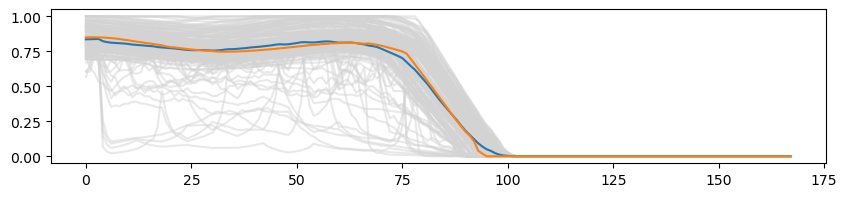

In [6]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper-1.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

asset = 0
time = 120
day = 30

# Get functional predictors for a given test
f_ = F_ts_[day, :time, asset]
f_hat_ = F_ts_[day, time:, asset]
e_ = E_ts_[day, :, asset]
e_lin_ = E_ts_lin_[day, :, asset]
e_bias_ = E_ts_bias_[day, :, asset]
x_ts = x_ts_[asset, :]
t_ts = t_ts_[day]

# Filter solar hours with loading solar set
idx_days_ = np.absolute(t_tr_ - day) < 7
print(idx_days_.shape, F_tr_.shape, E_tr_bias_.shape)
idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_bias_[idx_days_, :], axis = 0)) > 1.

_meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_ts, t_ts,
                                          forget_rate_f = hyper_.loc['forget_rate_f'][time],
                                          forget_rate_e = hyper_.loc['forget_rate_e'][time],
                                          length_scale_f = hyper_.loc['length_scale_f'][time],
                                          length_scale_e = hyper_.loc['length_scale_e'][time],
                                          lookup_rate = hyper_.loc['lookup_rate'][time],
                                          trust_rate = hyper_.loc['trust_rate'][time],
                                          nu = hyper_.loc['nu'][time],
                                          gamma = hyper_.loc['gamma'][time],
                                          xi = hyper_.loc['xi'][time],
                                          kappa = hyper_.loc['kappa'][time],
                                          p_fusion = hyper_.loc['p_fusion'][time],
                                          idx_hours_ = idx_hours_)

plt.figure(figsize=(10, 2))
plt.plot(M_.T, color = 'lightgray', alpha = 0.5)
plt.plot(_meta['focal_curve'])
plt.plot(f_hat_)
plt.show()

In [7]:
def _plot_PIT(_ax, u_, bins=10, title="PIT Histogram"):
    """
    Make a PIT histogram with a Uniform(0,1) reference line.
    Uses matplotlib, one chart, no explicit colors.
    """

    # histogram as density so the uniform reference is y=1
    counts_, bins, patches = _ax.hist(u_, 
                                     bins=bins, 
                                     range=(0.0, 1.0), 
                                     density=True, 
                                     edgecolor='black', 
                                     alpha = 0.5)   

    _ax.axhline(1.0, linestyle='--', color='red')
    _ax.set_xlim(0, 1)
    _ax.set_ylim(0, )

    _ax.set_xlabel("u = F̂(y_obs)")
    _ax.set_ylabel("Density")
    _ax.set_title(title)

def _KS(pit_):
    pit_ = np.asarray(pit_, dtype=float)
    pit_ = pit_[np.isfinite(pit_)]
    pit_ = np.clip(pit_, 0.0, 1.0)
    return stats.kstest(pit_, 'uniform').statistic

def _run_ffc(day, asset):

    file_name = f'{asset}-{day}-{time}'
    #print(f'Processing file {file_name}...')

    # Get functional predictors for a given test
    f_     = F_ts_[day, :time, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    e_     = E_ts_[day, :, asset]
    x_ts   = x_ts_[asset, :]
    t_ts   = t_ts_[day]
    f_hat_ = F_ts_[day, time:, asset]
    e_hat_ = E_ts_[day, time:, asset]

    # Filter solar hours with loading solar set
    #idx_days_  = np.absolute(t_tr_ - day) < 28
    #idx_hours_ = np.mean(F_tr_[idx_days_, :], axis = 0) > .25

    idx_days_  = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.
    
    _meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_ts, t_ts,
                                              forget_rate_f = hyper_.loc['forget_rate_f'][time],
                                              forget_rate_e = hyper_.loc['forget_rate_e'][time],
                                              length_scale_f = hyper_.loc['length_scale_f'][time],
                                              length_scale_e = hyper_.loc['length_scale_e'][time],
                                              lookup_rate = hyper_.loc['lookup_rate'][time],
                                              trust_rate = hyper_.loc['trust_rate'][time],
                                              gamma = hyper_.loc['gamma'][time],
                                              xi = hyper_.loc['xi'][time],
                                              nu = hyper_.loc['nu'][time],
                                              kappa = hyper_.loc['kappa'][time],
                                              p_fusion = hyper_.loc['p_fusion'][time], 
                                              idx_hours_ = idx_hours_)

    #M_p_, f_p_ = _bias_correction(M_, _meta['focal_curve'], bias_, time, scale = 0.5)
    M_p_ = M_ 
    f_p_ = _meta['focal_curve'].copy()

    N = np.array([_meta['idx_neighbors'].shape[0], 
                  _meta['idx_temporal'].shape[0], 
                  _meta['idx_spatial'].shape[0]])

    return [M_p_, f_hat_, e_hat_, f_p_, file_name, N]

def _run_parallel(n_workers = 32, 
                  assets_ = range(5), 
                  indices_ = range(363)):

    M_ = []
    f_hat_ = []
    e_hat_ = []
    focal_ = []
    date_ = []
    samples_ = []
    for asset in assets_:
        with mp.Pool(processes = n_workers) as pool:
            worker = partial(_run_ffc, asset=asset)
            results_ = pool.map(worker, indices_)
        M_ += [result[0] for result in results_]
        f_hat_ += [result[1] for result in results_]
        e_hat_ += [result[2] for result in results_]
        focal_ += [result[3] for result in results_]
        date_ += [result[4] for result in results_]
        samples_ += [result[5] for result in results_]

    print(len(M_), len(f_hat_), len(e_hat_), len(focal_), len(date_), len(samples_))
    
    return M_, f_hat_, e_hat_, focal_, date_, samples_

In [8]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper-1.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

time = 120

M_, f_hat_, e_hat_, focal_, date_, samples_ = _run_parallel(n_workers = 72, 
                                                            assets_ = range(20, 40, 1), 
                                                            indices_ = range(363))

                     120       132      144      168
parameter                                           
forget_rate_f     0.0625    0.0625    0.125    0.250
forget_rate_e     0.5000    0.5000    0.500    0.500
lookup_rate       8.0000   12.0000   16.000   32.000
length_scale_f    0.0500    0.0375    0.025    0.075
length_scale_e    0.5000    0.2500    0.100    0.100
trust_rate        0.5000    0.4500    0.400    0.300
nu                6.0000    7.0000    8.000   12.000
xi                0.5000    0.5500    0.600    0.800
gamma            30.0000   25.0000   20.000   10.000
kappa           150.0000  150.0000  150.000  150.000
p_fusion          0.9000    0.8000    0.700    0.600


7260 7260 7260 7260 7260 7260


In [9]:
U_ = []
B_ = []
E_ = []
S_ = []
F_ = []
N_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    E_ += [np.sqrt(np.mean((f_hat_[i] - e_hat_[i])**2))]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
    F_ += [focal_[i].mean()]
    N_ += [samples_[i]]
U_ = np.array(U_)
B_ = np.array(B_)
E_ = np.array(E_)
S_ = np.array(S_)
F_ = np.array(F_)
N_ = np.stack(N_)
print(U_.shape, B_.shape, E_.shape, S_.shape, F_.shape, N_.shape)

df_1_ = pd.DataFrame({"date": date_, "std": S_, "mean": F_, "error": E_})
df_1_[['asset', 'day', 'interval']] = df_1_['date'].str.split('-', expand=True)
df_1_['n_temporal'] = N_[:, 0]
df_1_['n_neigbors'] = N_[:, 1]
df_1_['n_spatial'] = N_[:, 2]

df_1_.drop(columns = ['date'], inplace = True)
print(df_1_)

pd.DataFrame(U_).to_csv(path_to_validation + f'/{resource}_{method}_{time}_ts.csv', index = False)

(7260, 168) (7260, 168) (7260,) (7260,) (7260,) (7260, 3)
           std      mean     error asset  day interval  n_temporal  \
0     0.103842  0.149234  0.189247    20    0      120       13869   
1     0.091548  0.118147  0.327259    20    1      120        9824   
2     0.105967  0.278717  0.067963    20    2      120       13470   
3     0.101195  0.256143  0.096262    20    3      120       12266   
4     0.087106  0.352036  0.081995    20    4      120       25356   
...        ...       ...       ...   ...  ...      ...         ...   
7255  0.093411  0.154342  0.068959    39  358      120       11672   
7256  0.085054  0.100720  0.172476    39  359      120       10190   
7257  0.088351  0.135154  0.117680    39  360      120        9226   
7258  0.073649  0.292755  0.074628    39  361      120       31873   
7259  0.088664  0.113725  0.135815    39  362      120       13308   

      n_neigbors  n_spatial  
0           3813        150  
1           3048        150  
2          

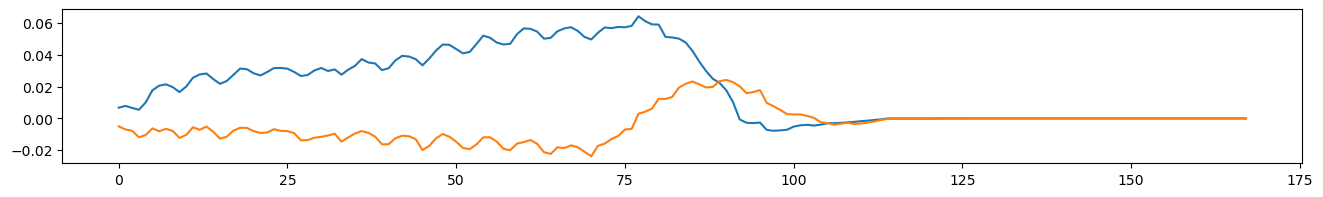

0.06418189721814921 0.024178163604308144


In [10]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

KS for lead time 1h: 0.05713187236550543
KS for lead time 2h: 0.1709641873278237
KS for lead time 3h: 0.11823863229886189
KS for lead time 4h: 0.1595671916261474


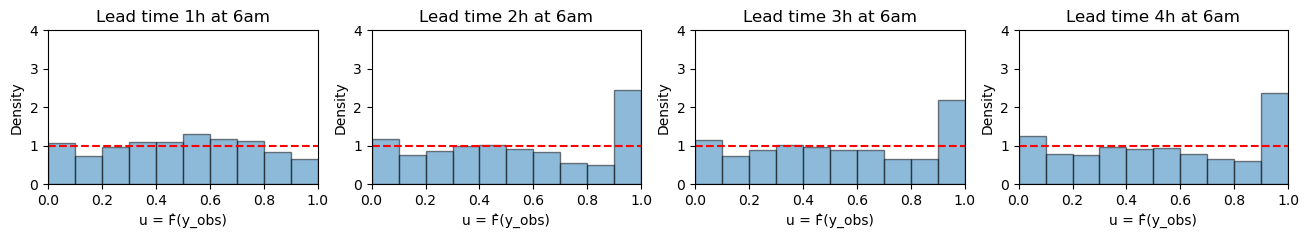

KS over lead times: 0.5059018836183384


In [11]:
lead = 1
bins = 10

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, 4, figsize=(16, 2))  

for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
                bins = bins, 
                title = f'Lead time {i + lead}h at 6am')
    
    ax[i].set_ylim(0, 4)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 1h: 0.02927685950413217
KS for lead time 2h: 0.027984389348025718
KS for lead time 3h: 0.02935953525708801
KS for lead time 4h: 0.053406795224977044
KS for lead time 5h: 0.06842745638200176


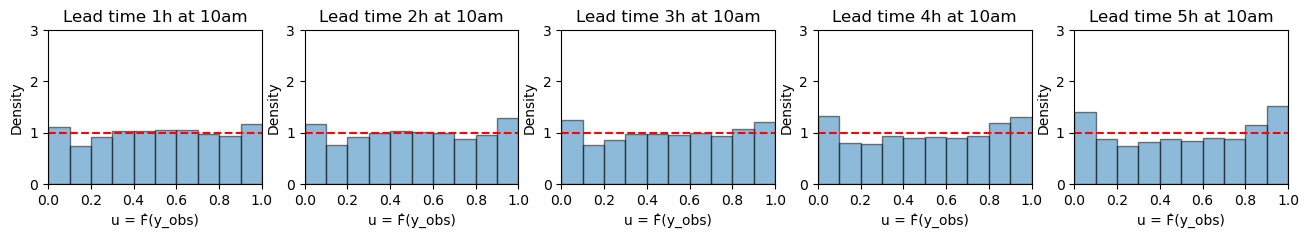

KS over lead times: 0.2084550357162247


In [12]:
lead = 1
bins = 10
n_intervals = 5

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  

for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, (i + lead)*12:(i + lead + 1)*12].flatten(), 
            bins = bins, 
            title = f'Lead time {i + lead}h at 10am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*12:(i + lead + 1)*12].flatten())
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

In [15]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper-1.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)

# hyper_.loc['gamma', 132] = 30
# hyper_.loc['length_scale_e', 132] = 0.25
# hyper_.loc['lookup_rate', 132] = 32
# hyper_.loc['p_fusion', 132] = 0.9

print(hyper_)

time = 144

M_, f_hat_, e_hat_, focal_, date_, samples_ = _run_parallel(n_workers = 72, 
                                                            assets_ = range(20, 40, 1), 
                                                            indices_ = range(363))

                     120       132      144      168
parameter                                           
forget_rate_f     0.0625    0.0625    0.125    0.250
forget_rate_e     0.5000    0.5000    0.500    0.500
lookup_rate       8.0000   12.0000   16.000   32.000
length_scale_f    0.0500    0.0375    0.025    0.075
length_scale_e    0.5000    0.2500    0.100    0.100
trust_rate        0.5000    0.4500    0.400    0.300
nu                6.0000    7.0000    8.000   12.000
xi                0.5000    0.5500    0.600    0.800
gamma            30.0000   25.0000   20.000   10.000
kappa           150.0000  150.0000  150.000  150.000
p_fusion          0.9000    0.8000    0.700    0.600
7260 7260 7260 7260 7260 7260


In [16]:
U_ = []
B_ = []
E_ = []
S_ = []
F_ = []
N_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    E_ += [np.sqrt(np.mean((f_hat_[i] - e_hat_[i])**2))]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
    F_ += [focal_[i].mean()]
    N_ += [samples_[i]]
U_ = np.array(U_)
B_ = np.array(B_)
E_ = np.array(E_)
S_ = np.array(S_)
F_ = np.array(F_)
N_ = np.stack(N_)
print(U_.shape, B_.shape, E_.shape, S_.shape, F_.shape, N_.shape)

df_2_ = pd.DataFrame({"date": date_, "std": S_, "mean": F_, "error": E_})
df_2_[['asset', 'day', 'interval']] = df_2_['date'].str.split('-', expand=True)
df_2_['n_neighbors'] = N_[:, 0]
df_2_['n_temporal'] = N_[:, 1]
df_2_['n_spatial'] = N_[:, 2]
df_2_.drop(columns = ['date'], inplace = True)
print(df_2_)

pd.DataFrame(U_).to_csv(path_to_validation + f'/{resource}_{method}_{time}_ts-4.csv', index = False)

(7260, 144) (7260, 144) (7260,) (7260,) (7260,) (7260, 3)
           std      mean     error asset  day interval  n_neighbors  \
0     0.098290  0.188022  0.155684    20    0      144         3901   
1     0.091570  0.120104  0.306773    20    1      144         2052   
2     0.060475  0.281760  0.060237    20    2      144        15070   
3     0.063504  0.231028  0.102330    20    3      144         4825   
4     0.059308  0.273809  0.079333    20    4      144        13094   
...        ...       ...       ...   ...  ...      ...          ...   
7255  0.060876  0.099784  0.051761    39  358      144         2863   
7256  0.058521  0.066347  0.169046    39  359      144         2988   
7257  0.045963  0.240174  0.088488    39  360      144        11787   
7258  0.043126  0.243058  0.069283    39  361      144        13018   
7259  0.063536  0.076060  0.111612    39  362      144         3531   

      n_temporal  n_spatial  
0            931        150  
1            620        150  

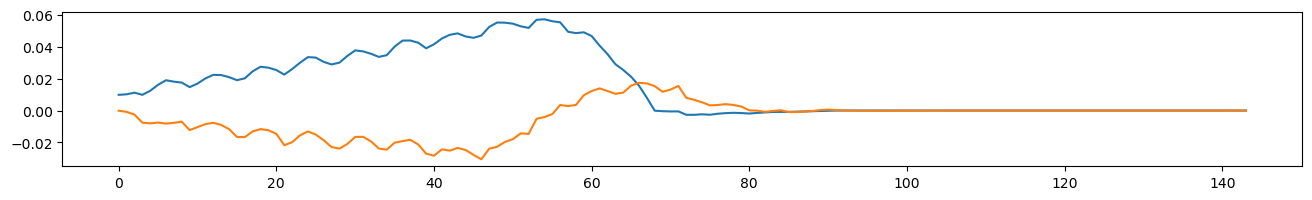

0.05723459289624905 0.03057221089800102


In [17]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

KS for lead time 1h: 0.04123585243133221
KS for lead time 2h: 0.169825813535748
KS for lead time 3h: 0.14129476584022038
KS for lead time 4h: 0.11093663911845719


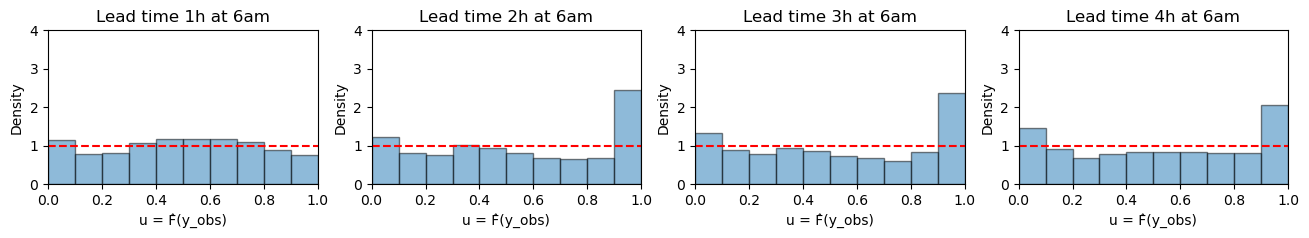

KS over lead times: 0.4632930709257578


In [18]:
lead = 1
bins = 10

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, 4, figsize=(16, 2))  

for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
                bins = bins, 
                title = f'Lead time {i + lead}h at 6am')
    
    ax[i].set_ylim(0, 4)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 1h: 0.02963728191000918
KS for lead time 2h: 0.048156344897204995
KS for lead time 3h: 0.06025711662075306
KS for lead time 4h: 0.0648966942148761
KS for lead time 5h: 0.07542240587695126


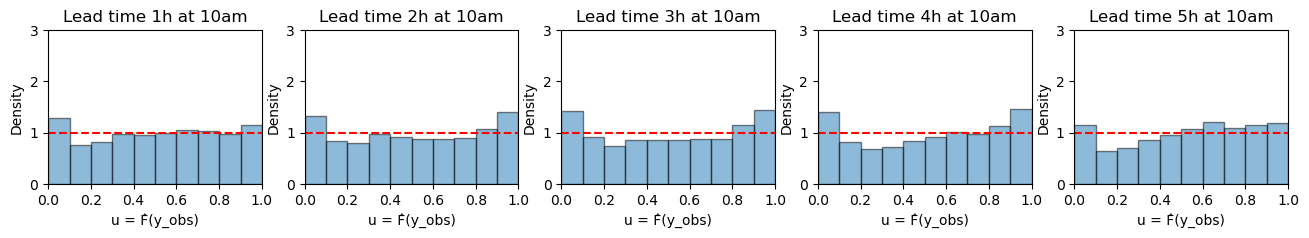

KS over lead times: 0.2783698435197946


In [19]:
lead = 1
bins = 10
n_intervals = 5

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  

for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, (i + lead)*12:(i + lead + 1)*12].flatten(), 
                bins = bins, 
                title = f'Lead time {i + lead}h at 10am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*12:(i + lead + 1)*12].flatten())
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

In [20]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper-1.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)

# hyper_.loc['gamma', 132] = 30
# hyper_.loc['length_scale_e', 132] = 0.25
# hyper_.loc['lookup_rate', 132] = 32

print(hyper_)

time = 168

M_, f_hat_, e_hat_, focal_, date_, samples_ = _run_parallel(n_workers = 72, 
                                                            assets_ = range(20, 40, 1), 
                                                            indices_ = range(363))

                     120       132      144      168
parameter                                           
forget_rate_f     0.0625    0.0625    0.125    0.250
forget_rate_e     0.5000    0.5000    0.500    0.500
lookup_rate       8.0000   12.0000   16.000   32.000
length_scale_f    0.0500    0.0375    0.025    0.075
length_scale_e    0.5000    0.2500    0.100    0.100
trust_rate        0.5000    0.4500    0.400    0.300
nu                6.0000    7.0000    8.000   12.000
xi                0.5000    0.5500    0.600    0.800
gamma            30.0000   25.0000   20.000   10.000
kappa           150.0000  150.0000  150.000  150.000
p_fusion          0.9000    0.8000    0.700    0.600
7260 7260 7260 7260 7260 7260


In [21]:
U_ = []
B_ = []
E_ = []
S_ = []
F_ = []
N_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    E_ += [np.sqrt(np.mean((f_hat_[i] - e_hat_[i])**2))]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
    F_ += [focal_[i].mean()]
    N_ += [samples_[i]]
U_ = np.array(U_)
B_ = np.array(B_)
E_ = np.array(E_)
S_ = np.array(S_)
F_ = np.array(F_)
N_ = np.stack(N_)
print(U_.shape, B_.shape, E_.shape, S_.shape, F_.shape, N_.shape)

df_3_ = pd.DataFrame({"date": date_, "std": S_, "mean": F_, "error": E_})
df_3_[['asset', 'day', 'interval']] = df_3_['date'].str.split('-', expand=True)
df_3_['n_neighbors'] = N_[:, 0]
df_3_['n_temporal'] = N_[:, 1]
df_3_['n_spatial'] = N_[:, 2]
df_3_.drop(columns = ['date'], inplace = True)
print(df_3_)

pd.DataFrame(U_).to_csv(path_to_validation + f'/{resource}_{method}_{time}_ts-22.csv', index = False)

(7260, 120) (7260, 120) (7260,) (7260,) (7260,) (7260, 3)
           std      mean     error asset  day interval  n_neighbors  \
0     0.050905  0.168881  0.143470    20    0      168         2595   
1     0.063923  0.063652  0.284420    20    1      168          576   
2     0.040937  0.205245  0.057955    20    2      168        12203   
3     0.060069  0.143373  0.109752    20    3      168         2908   
4     0.035990  0.199373  0.079660    20    4      168         9136   
...        ...       ...       ...   ...  ...      ...          ...   
7255  0.049981  0.041012  0.049202    39  358      168         2591   
7256  0.044542  0.039694  0.096252    39  359      168         1317   
7257  0.036115  0.161578  0.078517    39  360      168         5764   
7258  0.037800  0.162948  0.049275    39  361      168         8067   
7259  0.054327  0.066770  0.087231    39  362      168         2866   

      n_temporal  n_spatial  
0            365        150  
1            140        150  

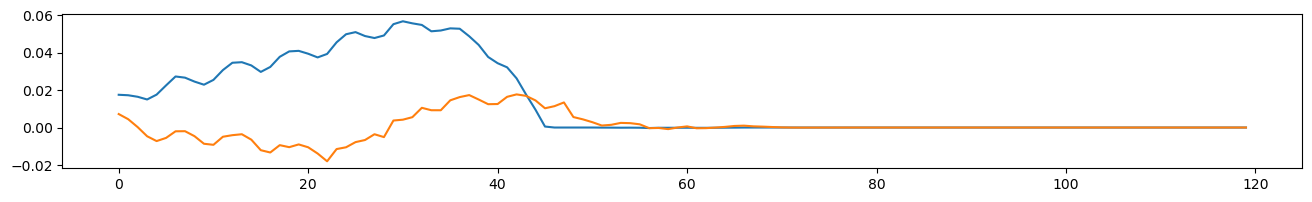

0.05680409376874218 0.01804230565400736


In [22]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

KS for lead time 1h: 0.03088154269972454
KS for lead time 2h: 0.1368167154356329
KS for lead time 3h: 0.13085057048348625
KS for lead time 4h: 0.2070353755186069


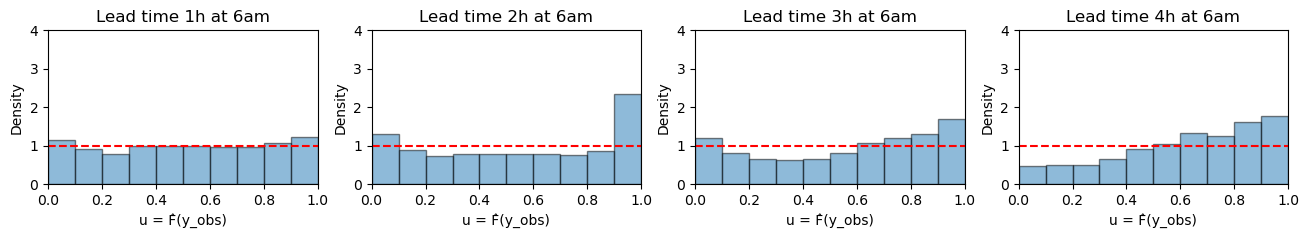

KS over lead times: 0.5055842041374505


In [23]:
lead = 1
bins = 10

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, 4, figsize=(16, 2))  

for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
                bins = bins, 
                title = f'Lead time {i + lead}h at 6am')
    
    ax[i].set_ylim(0, 4)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 1h: 0.07237373737373731
KS for lead time 2h: 0.10250207492475316
KS for lead time 3h: 0.10328053259871434
KS for lead time 4h: 0.07583333333333331
KS for lead time 5h: 0.09740261729949884


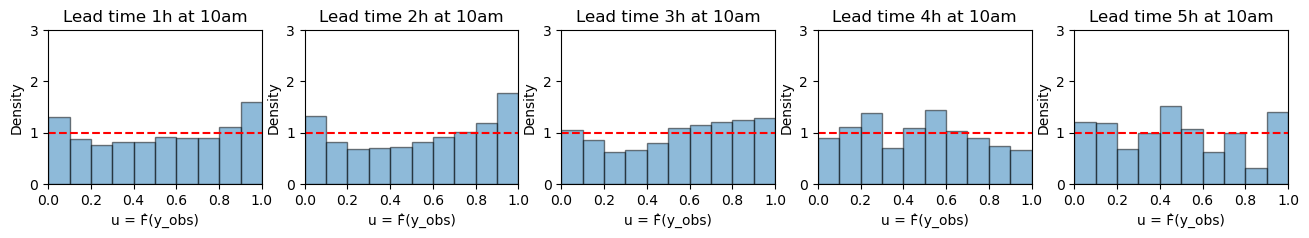

KS over lead times: 0.45139229553003696


In [24]:
lead = 1
bins = 10
n_intervals = 5

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  

for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, (i + lead)*12:(i + lead + 1)*12].flatten(), 
                bins = bins, 
                title = f'Lead time {i + lead}h at 10am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*12:(i + lead + 1)*12].flatten())
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

In [23]:
df_ = pd.concat([df_1_, df_2_, df_3_], axis = 0)    
print(df_.shape)

df_.to_csv(path_to_validation + f'/{resource}_{method}_dispersion_ts.csv', index = False)

(21780, 10)


In [8]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

time = 132

M_, f_hat_, e_hat_, focal_, date_, samples_ = _run_parallel(n_workers = 72, 
                                                            assets_ = range(20, 40, 1), 
                                                            indices_ = range(363))

                     120       132       144       168
parameter                                             
forget_rate_f     0.0625    0.0625    0.0625    0.0625
forget_rate_e     1.0000    0.7500    0.5000    0.2500
lookup_rate      64.0000   32.0000   16.0000    8.0000
length_scale_f    0.0100    0.0175    0.0250    0.0750
length_scale_e    0.2500    0.2500    0.2500    0.2500
trust_rate        0.5000    0.4500    0.4000    0.3000
nu                4.0000    6.0000    8.0000   12.0000
xi                0.5000    0.5500    0.6000    0.8000
gamma            30.0000   30.0000   30.0000   30.0000
kappa           175.0000  175.0000  175.0000  175.0000
p_fusion          0.9000    0.9000    0.9000    0.9000
7260 7260 7260 7260 7260 7260


In [9]:
U_ = []
B_ = []
E_ = []
S_ = []
F_ = []
N_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    E_ += [np.sqrt(np.mean((f_hat_[i] - e_hat_[i])**2))]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
    F_ += [focal_[i].mean()]
    N_ += [samples_[i]]
U_ = np.array(U_)
B_ = np.array(B_)
E_ = np.array(E_)
S_ = np.array(S_)
F_ = np.array(F_)
N_ = np.stack(N_)
print(U_.shape, B_.shape, E_.shape, S_.shape, F_.shape, N_.shape)

df_4_ = pd.DataFrame({"date": date_, "std": S_, "mean": F_, "error": E_})
df_4_[['asset', 'day', 'interval']] = df_4_['date'].str.split('-', expand=True)
df_4_['n_temporal'] = N_[:, 0]
df_4_['n_neigbors'] = N_[:, 1]
df_4_['n_spatial'] = N_[:, 2]
df_4_.drop(columns = ['date'], inplace = True)
print(df_4_)

pd.DataFrame(U_).to_csv(path_to_validation + f'/{resource}_{method}_{time}_ts.csv', index = False)

(7260, 156) (7260, 156) (7260,) (7260,) (7260,) (7260, 3)
           std      mean     error asset  day interval  n_temporal  \
0     0.103301  0.177930  0.164470    20    0      132        3612   
1     0.081376  0.098415  0.319179    20    1      132        4700   
2     0.050071  0.325576  0.063393    20    2      132       15758   
3     0.087478  0.256687  0.099316    20    3      132        6792   
4     0.052113  0.316479  0.077353    20    4      132       13423   
...        ...       ...       ...   ...  ...      ...         ...   
7255  0.072501  0.124213  0.058828    39  358      132        4429   
7256  0.077656  0.094632  0.171192    39  359      132        5861   
7257  0.052844  0.267651  0.094343    39  360      132       11195   
7258  0.056442  0.271040  0.070037    39  361      132       14681   
7259  0.087697  0.140491  0.121110    39  362      132        2518   

      n_neigbors  n_spatial  
0            908        175  
1           1820        175  
2          

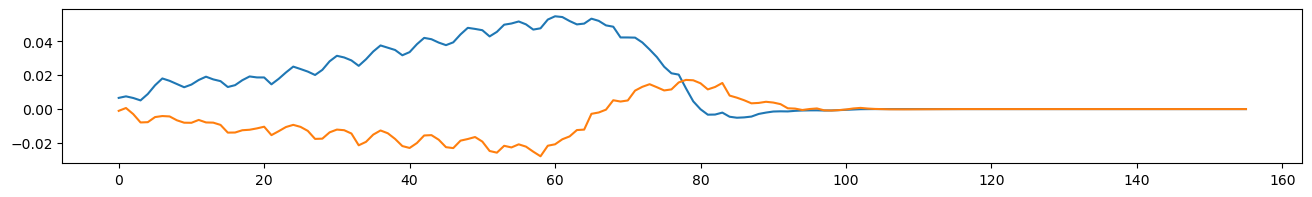

0.05477607089493125 0.02785296565576535


In [10]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

KS for lead time 1h: 0.07750368893024395
KS for lead time 2h: 0.16062462216192708
KS for lead time 3h: 0.12323988292523935
KS for lead time 4h: 0.148642266824085


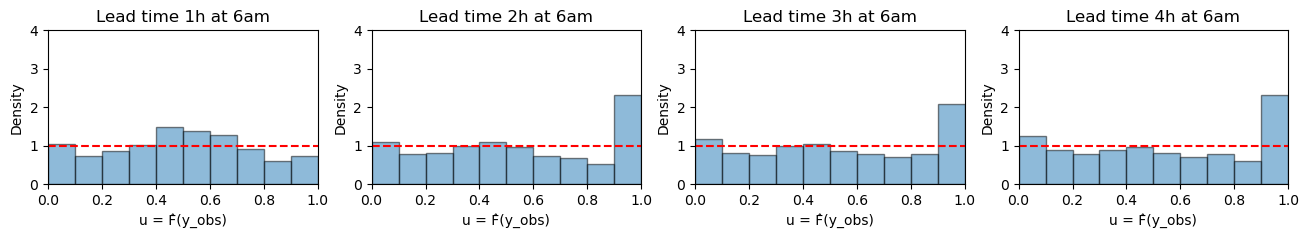

KS over lead times: 0.5100104608414954


In [11]:
lead = 1
bins = 10

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, 4, figsize=(16, 2))  

for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
                bins = bins, 
                title = f'Lead time {i + lead}h at 6am')
    
    ax[i].set_ylim(0, 4)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 1h: 0.029775678866587996
KS for lead time 2h: 0.025081004853732117
KS for lead time 3h: 0.029512003148366786
KS for lead time 4h: 0.043668831168831135
KS for lead time 5h: 0.05023213839221974


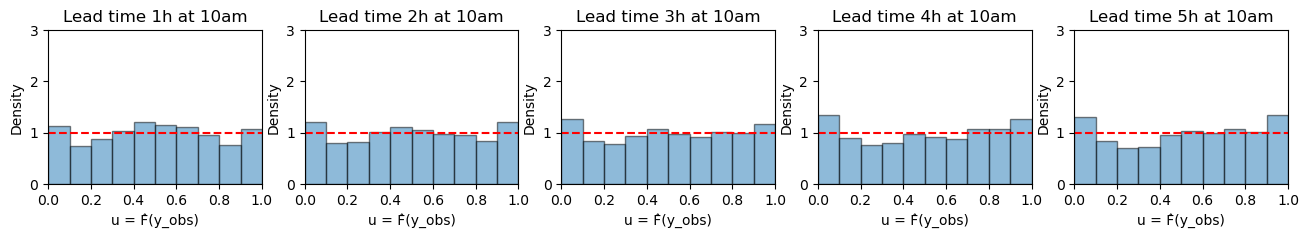

KS over lead times: 0.17826965642973777


In [ ]:
lead = 1
bins = 10
n_intervals = 5

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  

for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, (i + lead)*12:(i + lead + 1)*12].flatten(), 
                bins = bins, 
                title = f'Lead time {i + lead}h at 10am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*12:(i + lead + 1)*12].flatten())
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')
# KS over lead times: 0.21283810233743627
# KS over lead times: 0.17826965642973777


In [31]:
df_ = pd.concat([df_1_, df_2_, df_3_, df_4_], axis = 0)    
print(df_.shape)

df_.to_csv(path_to_validation + f'/{resource}_{method}_dispersion_ts.csv', index = False)

(29040, 10)
